<a href="https://colab.research.google.com/github/christianlee479/CPSC-2200/blob/main/Copy_of_CPSC_2200_DLP_chapter08_image_classification(ChristianLee).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Yale University


# CPSC 2200 Introduction to Data Analysis and Machine Learning for Humanities and Social Sciences

**Instructor**: Sohee Park

Department of Computer Science

This is a notebook generated for CPSC 2200, a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

**Learning Objectives:**

This module covers

* Understanding convolutional neural networks (ConvNets)
* Using data augmentation to mitigate overfitting
* Using a pretrained  ConvNet for feature extraction
* Fine-tunning a pretrained ConvNet

In [ ]:
!pip install keras keras-hub==0.21.1 --upgrade -q   # 0.21.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.0 MB/s eta 0:00:00


In [ ]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [ ]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Image classification

In this chapter we will learn about convolutional neural networks, also known as ConvNets or CNNs, the type of deep-learning model that is used by most computer vision applications.
We apply ConvNets to image classification problems with small training datasets due to their capabilities which will see next.

### Introduction to ConvNets

First we start with the basic structure.
The following example uses a ConvNet to classify MNIST digits, a task we performed in chapter 2 using a densely connected network (our test accuracy then was 97.8%). Even though the ConvNet will be basic, its accuracy will overcome that of the densely connected model from chapter 2.

A ConvNet iss a stack of Conv2D and MaxPooling2D layers.
It takes as input tensors of shape (image_height, image_width, image_channels) (not including the batch dimension).
In this case, we'll configure the ConvNet to process inputs of size (28, 28, 1), which is the format of MNIST images.

In [ ]:
import keras
from keras import layers

# to create a Convolutional Neural Network, we stack
# together Conv2D and MaxPooling2D layers
inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(inputs)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

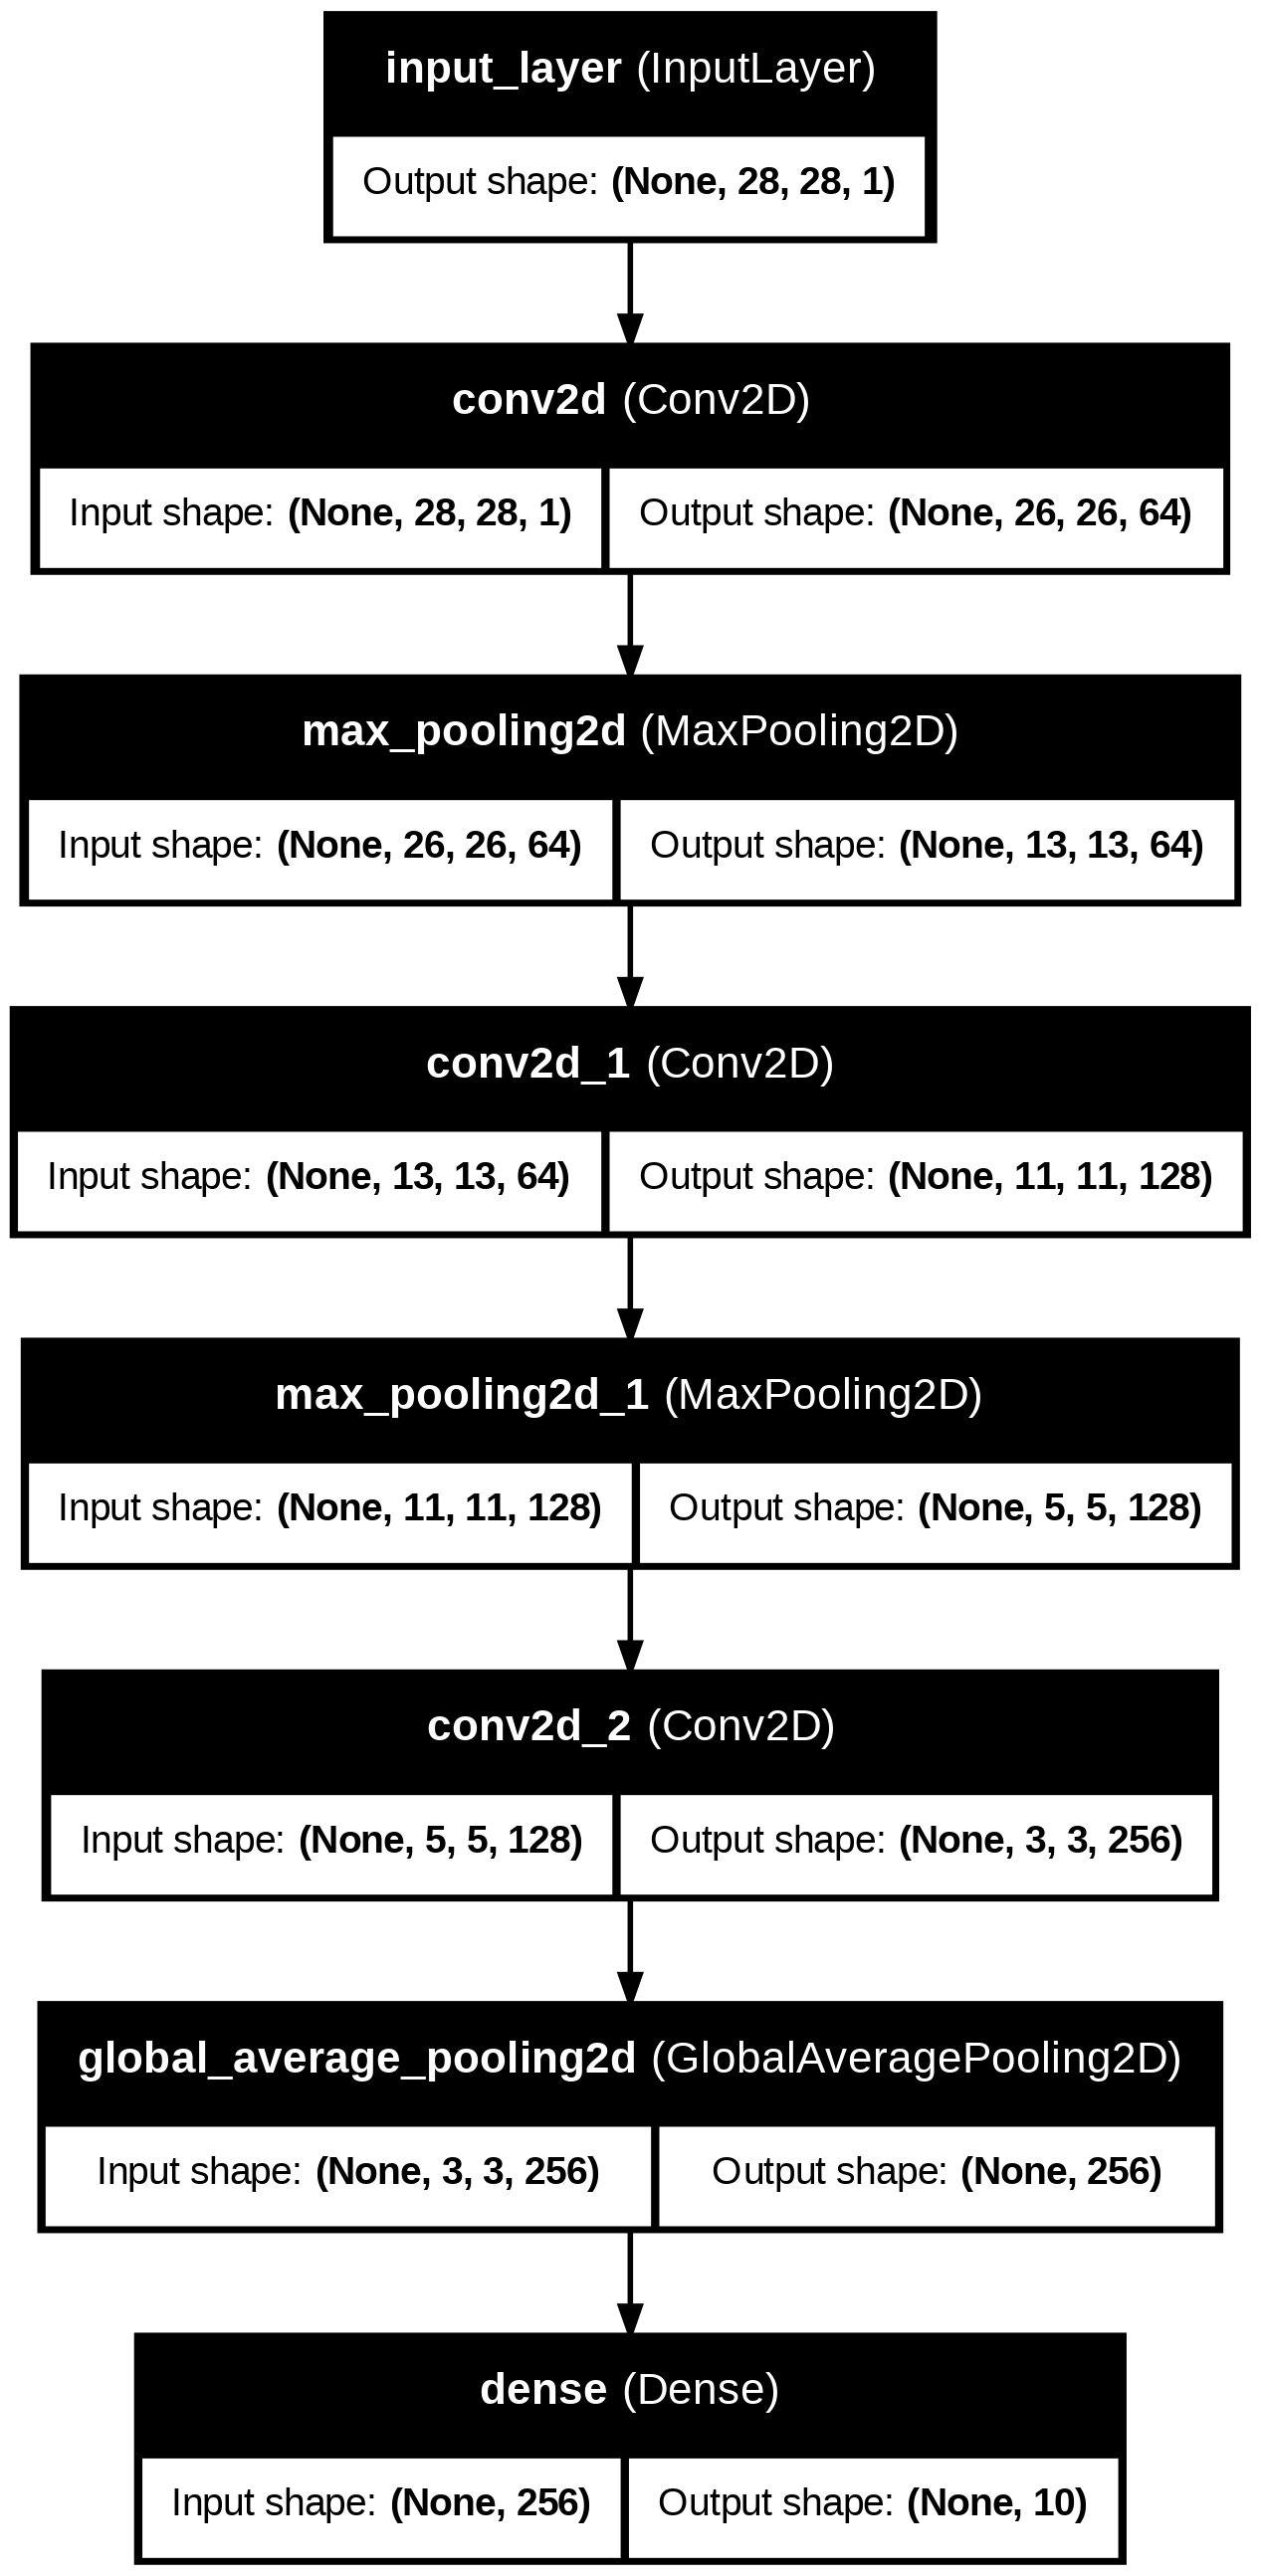

In [ ]:
from keras.utils import plot_model

plot_model(model, to_file="cnn_model.png", show_shapes=True, show_layer_names=True)


In [ ]:
model.summary(line_length=80)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)          │ (None, 28, 28, 1)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d (Conv2D)                   │ (None, 26, 26, 64)       │           640 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)      │ (None, 13, 13, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)                 │ (None, 11, 11, 128)      │        73,856 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)    │ (None, 5, 5, 128)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)                 │ (None, 3, 3, 256)        │       295,168 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 256)              │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 10)               │         2,570 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 372,234 (1.42 MB)

 Trainable params: 372,234 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

The output of every Conv2D and MaxPooling2D layer is a 3D tensor of shape (height, width, channels). The width and height dimensions tend to shrink as you go deeper in the model. The number of channels is controlled by the first argument passed to the Conv2D layers (64, 128, or 256).
After the last Conv2D layer, we end up with an output of shape (3, 3, 256) — a 3 x 3 feature map of 256 channels.
The next step is to feed this output into a densely connected classifier: a stack of Dense layers.
These classifiers process vectors, which are 1D, whereas the current output is a rank-3 tensor.

To bridge the gap, we flatten the 3D outputs to 1D with a GlobalAveragePooling2D layer before adding the Dense layers. This layer will take the average of each 3 x 3 feature map in the tensor of shape (3, 3, 256), resulting in an output vector of shape (256,).
Finally, we'll do 10-way classification, so our last layer has 10 outputs and a softmax activation.

---

Now let's use the mnist dataset to train our ConvNet.

In [ ]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
# Reshape train_images to shape (60000, 28, 28, 1)
train_images = train_images.reshape(60000, 28, 28, 1)
# Normalize as 'float32' (/255)
train_images = train_images.astype("float32")/255
# Reshape test_images to shape (10000, 28, 28, 1)
test_images = test_images.reshape(10000, 28, 28, 1)
# Normalize
test_images = test_images.astype("float32")/255

# Compile model with:
# optimizer: adam
# loss: sparse_categorical_crossentropy
# metrics: accuracy
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)
# fit model for 5 epochs and batch_size: 64
model.fit(train_images, train_labels,
          epochs = 5,
          batch_size = 64
          )

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9165 - loss: 0.2614
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9780 - loss: 0.0703
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9857 - loss: 0.0463
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9887 - loss: 0.0364
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9910 - loss: 0.0285


In [ ]:
# evaluate model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9908 - loss: 0.0293
Test accuracy: 0.991


Whereas the densely connected model from chapter 2 had a test accuracy of 97.8%, the basic ConvNet has a test accuracy of 99.1%: we decreased the error rate by about 60% (relative).

#### The convolution operation

The fundamental difference between a densely connected layer and a convolution layer is this: Dense layers learn global patterns in their input feature space (for example, for a MNIST digit, patterns involving all pixels), whereas convolution layers learn local patterns (see figure 8.1): in the case of images, patterns found in small 2D windows of the inputs. In the previous example, these windows were all 3 x 3

##### Understanding border effects and padding

Consider a 5 x 5 feature map (25 tiles total). There are only 9 tiles around which you can center a 3 x 3 window, forming a 3 x 3 grid.
Hence, the output feature map will be 3 x 3. It shrinks a little: by exactly two tiles alongside each dimension, in this case.
You can see this border effect in action in the earlier example: you start with 28 x 28 inputs, which become 26 x 26 after the first convolution layer.

![Valid locations of 3 x 3 patches in a 5 x 5 input feature map](http://deeplearningwithpython.io/images/ch08/3x3_patches_in_5x5_input.3954b81b.png)

If you want to get an output feature map with the same spatial dimensions as the input, you can use padding. Padding consists of adding an appropriate number of rows and columns on each side of the input feature map so as to make it possible to fit centered convolution windows around every input tile. For a 3 x 3 window, you add one column on the right, one column on the left, one row at the top, and one row at the bottom. For a 5 x 5 window, you add two rows.

![Padding a 5 × 5 input to be able to extract 25 3 × 3 patches](https://deeplearningwithpython.io/images/ch08/padding_of_5x5_input.fb864a53.png)

##### Understanding convolution strides

The other factor that can influence output size is the notion of strides.
The description of convolution so far has assumed that the center tiles of the convolution windows are all contiguous. But the distance between two successive windows is a parameter of the convolution, called its stride, which defaults to 1.
It's possible to have strided convolutions: convolutions with a stride higher than 1.
In the figure below, you can see the patches extracted by a 3 x 3 convolution with stride 2 over a 5 x 5 input (without padding).

![3 x 3 convolution patches with 2 x 2 strides](https://deeplearningwithpython.io/images/ch08/strides.78c3a935.png)

#### The max-pooling operation

In the ConvNet example, you may have noticed that the size of the feature maps is halved after every MaxPooling2D layer.
For instance, before the first MaxPooling2D layers, the feature map is 26 x 26, but the max-pooling operation halves it to 13 x 13.
That's the role of max pooling: to aggressively downsample feature maps, much like strided convolutions.

Max pooling consists of extracting windows from the input feature maps and outputting the max value of each channel.
It's conceptually similar to convolution, except that instead of transforming local patches via a learned linear transformation (the convolution kernel), they're transformed via a hardcoded max tensor operation.
A big difference from convolution is that max pooling is usually done with 2 x 2 windows and stride 2 to downsample the feature maps by a factor of 2. On the other hand, convolution is typically done with 3 x 3 windows and no stride (stride 1).

Why downsample feature maps this way? Why not remove the max-pooling layers and keep fairly large feature maps all the way up? Let's look at this option. Our model would then look like this.

In [ ]:

outputs = layers.Dense(10, activation="softmax")(x)


inputs = keras.Input(shape=(28, 28, 1))
# create a Conv2D taking inputs with 64 filters, kernel_size 3 and 'relu' activation
x = layers.Conv2D(filters=64, kernel_size=3, activation='relu')(inputs)
# create a Conv2D layer with 128 filters, kernel_size 3 and 'relu' activation
x = layers.Conv2D(filters=64, kernel_size=3, activation='relu')(x)
# create a Conv2D layer with 256 filters, kernel_size 3 and 'relu' activation
x = layers.Conv2D(filters=64, kernel_size=3, activation='relu')(x)
# create a GlobalAveragePooling2D layer
x = layers.GlobalAveragePooling2D()(x)
# create a Dense layer with 10 dims and 'softmax' activation
outputs = layers.Dense(10, activation='softmax')(x)
model_no_max_pool = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model_no_max_pool.summary(line_length=80)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)        │ (None, 28, 28, 1)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)                 │ (None, 26, 26, 64)       │           640 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)                 │ (None, 24, 24, 64)       │        36,928 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)                 │ (None, 22, 22, 64)       │        36,928 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d_1        │ (None, 64)               │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_2 (Dense)                   │ (None, 10)               │           650 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 75,146 (293.54 KB)

 Trainable params: 75,146 (293.54 KB)

 Non-trainable params: 0 (0.00 B)

What's wrong with this setup?

- It isn't conducive to learning a spatial hierarchy of features. The 3 x 3 windows in the third layer will only contain information coming from 7 x 7 windows in the initial input.
The high-level patterns learned by the ConvNet will still be very small with regard to the initial input, which may not be enough to learn to classify digits (try recognizing a digit by only looking at it through windows that are 7 x 7 pixels!).
We need the features from the last convolution layer to contain information about the totality of the input.

- The final feature map has dimensions 22 x 22. That's huge — when you take the average of each 22 x 22 feature map, you are going to be destroying a lot of information compared to when your feature maps were only 3  3.

The reason to use downsampling is to reduce the size of the feature maps, making the information they contain increasingly less spatially distributed and increasingly contained in the channels, while also inducing spatial-filter hierarchies by making successive convolution layers “look” at increasingly large windows (in terms of the fraction of the original input image they cover).

### Training a ConvNet from scratch on a small dataset

Having to train an image-classification model using very little data is a common situation, which you'll likely encounter in practice if you ever do computer vision in a professional context. A “few” samples can mean anywhere from a few hundred to a few tens of thousands of images. As a practical example, we'll focus on classifying images as dogs or cats. We'll work with a dataset containing 5,000 pictures of cats and dogs (2,500 cats, 2,500 dogs), taken from the original Kaggle dataset. We'll use 2,000 pictures for training, 1,000 for validation, and 2,000 for testing.

In this section, we'll review one basic strategy to tackle this problem: training a new model from scratch using what little data we have. We'll start by naively training a small ConvNet on the 2,000 training samples, without any regularization, to set a baseline for what can be achieved. This will get us to a classification accuracy of about 80%. At that point, the main issue will be overfitting. Then we'll introduce data augmentation, a powerful technique for mitigating overfitting in computer vision. By using data augmentation, we'll improve the model to reach a test accuracy of about 84%.

#### The relevance of deep learning for small-data problems

It isn't possible to train a ConvNet to solve a complex problem with just a few tens of samples, but a few hundred can potentially suffice if the model is small and well regularized and the task is simple. Because ConvNets learn local, translation-invariant features, they're highly data efficient on perceptual problems. Training a ConvNet from scratch on a very small image dataset will still yield reasonable results despite a relative lack of data, without the need for any custom feature engineering.

Deep learning models are by nature highly repurposable: you can take, say, an image-classification or speech-to-text model trained on a large-scale dataset and reuse it on a significantly different problem with only minor changes.
Specifically, in the case of computer vision, many pretrained classification models are publicly available for download and can be used to bootstrap powerful vision models out of very little data. This is one of the greatest strengths of deep learning: feature reuse.

#### Downloading the data

In [ ]:
import kagglehub
import os
import shutil

# 1. Download latest version
path = kagglehub.dataset_download("tongpython/cat-and-dog")
print("Path to dataset files:", path)

# 2. Define source and destination base paths
src_base = path
dst_base = 'cat-and-dog'

# Define the sub-splits we want to create
categories = ['cats', 'dogs']
sub_dirs = ['train', 'validation', 'test']

# 3. Create the directory structure
for sub in sub_dirs:
    for cat in ['cat', 'dog']:
        os.makedirs(os.path.join(dst_base, sub, cat), exist_ok=True)

# 4. Helper function to move images
def distribute_images(category):
    # Map singular folder name for destination
    dst_cat = category[:-1] if category.endswith('s') else category

    # Source paths
    train_src = os.path.join(src_base, 'training_set', 'training_set', category)
    test_src = os.path.join(src_base, 'test_set', 'test_set', category)

    # Get sorted list of filenames to ensure consistency
    train_files = sorted(os.listdir(train_src))
    test_files = sorted(os.listdir(test_src))

    # Logic:
    # 0-2000 -> Train
    # 2000-3000 -> Validation
    # 3000-4000 + Test set -> Test

    # Train (First 2000)
    for f in train_files[:2000]:
        shutil.copy(os.path.join(train_src, f), os.path.join(dst_base, 'train', dst_cat, f))

    # Validation (Next 1000)
    for f in train_files[2000:3000]:
        shutil.copy(os.path.join(train_src, f), os.path.join(dst_base, 'validation', dst_cat, f))

    # Test (Remaining 1000 from train + All from test_set)
    for f in train_files[3000:4000]:
        shutil.copy(os.path.join(train_src, f), os.path.join(dst_base, 'test', dst_cat, f))
    for f in test_files:
        shutil.copy(os.path.join(test_src, f), os.path.join(dst_base, 'test', dst_cat, f"ext_{f}"))

# 5. Execute for both categories
for cg in categories:
    distribute_images(cg)
    print(f"Finished processing {cg}...")

print("Data reorganization complete!")

# Verify Dataset
new_base_dir = 'cat-and-dog'
for subset in ['train', 'validation', 'test']:
    for category in ['cat', 'dog']:
        dirname = 'cat-and-dog/'+subset+'/'+ category
        count = !ls {dirname} |wc -l
        print(dirname, count)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog
Finished processing cats...
Finished processing dogs...
Data reorganization complete!
cat-and-dog/train/cat ['2000']
cat-and-dog/train/dog ['2000']
cat-and-dog/validation/cat ['1000']
cat-and-dog/validation/dog ['1000']
cat-and-dog/test/cat ['2012']
cat-and-dog/test/dog ['2013']


We created a dataset containing three subsets: a training set with **2,000** samples of each class, a validation set with **1000** samples of each class, and a test set with **2,000** samples of each
class.

**Why do this?** Because many of the image datasets you'll encounter in your
career only contain a few thousand samples, not tens of thousands. Having more data
available would make the problem easier, so it's good practice to learn with a small
dataset.

#### Building your model

We will reuse the same general model structure: the ConvNet will be a stack of alternated Conv2D (with relu activation) and MaxPooling2D layers.

But because we are dealing with bigger images and a more complex problem, we will make our model large, accordingly.

In [ ]:
# Listing 8.7 Instantiating a small ConvNet for dogs vs. cats classification

import keras
from keras import layers

inputs = keras.Input(shape=(180, 180, 3))   # The model expects RGB image of size 180x180
x = layers.Rescaling(1.0 / 255)(inputs)     # Rescaling the image to the [0,1] range by dividing them by 255
# Conv2D layer with 32 filters, kernel_size: 3, relu
x = layers.Conv2D(filters=32, kernel_size=3, activation='relu')(x)
# MaxPooling2D layer with pool_size: 2
x = layers.MaxPooling2D(pool_size=2)(x)
# Conv2D layer with 64 filters, kernel_size: 3, relu
x = layers.Conv2D(filters=64, kernel_size=3, activation='relu')(x)
# MaxPooling2D layer with pool_size: 2
x = layers.MaxPooling2D(pool_size=2)(x)
# Conv2D layer with 128 filters, kernel_size: 3, relu
x = layers.Conv2D(filters=128, kernel_size=3, activation='relu')(x)
# MaxPooling2D layer with pool_size: 2
x = layers.MaxPooling2D(pool_size=2)(x)
# Conv2D layer with 256 filters, kernel_size: 3, relu
x = layers.Conv2D(filters=256, kernel_size=3, activation='relu')(x)
# MaxPooling2D layer with pool_size: 2
x = layers.MaxPooling2D(pool_size=2)(x)
# Conv2D layer with 512 filters, kernel_size: 3, relu
x = layers.Conv2D(filters=512, kernel_size=3, activation='relu')(x)
x = layers.GlobalAveragePooling2D()(x)
# Dense Output layer with 1 unit and sigmoid
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model.summary(line_length=80)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)        │ (None, 180, 180, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ rescaling (Rescaling)             │ (None, 180, 180, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)                 │ (None, 178, 178, 32)     │           896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)    │ (None, 89, 89, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)                 │ (None, 87, 87, 64)       │        18,496 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)    │ (None, 43, 43, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)                 │ (None, 41, 41, 128)      │        73,856 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)    │ (None, 20, 20, 128)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)                 │ (None, 18, 18, 256)      │       295,168 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)    │ (None, 9, 9, 256)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)                │ (None, 7, 7, 512)        │     1,180,160 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d_2        │ (None, 512)              │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_3 (Dense)                   │ (None, 1)                │           513 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 1,569,089 (5.99 MB)

 Trainable params: 1,569,089 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile the model using:
# - 'binary_crossentropy' loss function
# - 'adam' optimizer
# - 'accuracy' metrics

model.compile(
    loss = "binary_crossentropy",
    optimizer= "adam",
    metrics = ["accuracy"]
)

#### Data preprocessing

1. Read the picture files.
2. Decode the JPEG content to RGB grif of pixcels.
3. Convert these into floating-point tensors.
4. Resize them to a shared size (180x180 in our coding).
5. Pack them into batches (32 images in our example).

In [ ]:
from keras.utils import image_dataset_from_directory
from pathlib import Path

batch_size = 64
image_size = (180, 180)
train_dataset = image_dataset_from_directory(
    Path(f"{new_base_dir}/train"), image_size=image_size, batch_size=batch_size
)
validation_dataset = image_dataset_from_directory(
    Path(f"{new_base_dir}/validation"), image_size=image_size, batch_size=batch_size
)
test_dataset = image_dataset_from_directory(
    Path(f"{new_base_dir}/test"), image_size=image_size, batch_size=batch_size
)

Found 3998 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.
Found 4023 files belonging to 2 classes.


##### Understanding TensorFlow Dataset objects

In [ ]:
import numpy as np
import tensorflow as tf

random_numbers = np.random.normal(size=(1000, 16))
dataset = tf.data.Dataset.from_tensor_slices(random_numbers)

In [ ]:
for i, element in enumerate(dataset):
    print(element.shape)
    if i >= 2:
        break

(16,)
(16,)
(16,)


In [ ]:
batched_dataset = dataset.batch(32)
for i, element in enumerate(batched_dataset):
    print(element.shape)
    if i >= 2:
        break

(32, 16)
(32, 16)
(32, 16)


In [ ]:
reshaped_dataset = dataset.map(
    lambda x: tf.reshape(x, (4, 4)),
    num_parallel_calls=8)
for i, element in enumerate(reshaped_dataset):
    print(element.shape)
    if i >= 2:
        break

(4, 4)
(4, 4)
(4, 4)


##### Fitting the model

In [ ]:
for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break

data batch shape: (64, 180, 180, 3)
labels batch shape: (64,)


In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 249ms/step - accuracy: 0.5175 - loss: 0.6934 - val_accuracy: 0.5540 - val_loss: 0.6862
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 141ms/step - accuracy: 0.6068 - loss: 0.6629 - val_accuracy: 0.6105 - val_loss: 0.6612
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - accuracy: 0.6213 - loss: 0.6502 - val_accuracy: 0.6235 - val_loss: 0.6460
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.6656 - loss: 0.6215 - val_accuracy: 0.6725 - val_loss: 0.6104
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - accuracy: 0.6793 - loss: 0.6030 - val_accuracy: 0.6555 - val_loss: 0.6148
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - accuracy: 0.6836 - loss: 0.5972 - val_accuracy: 0.6850 - val_loss: 0.6001
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 129ms/step - accuracy: 0.7054 - loss: 0.5703 - val_accuracy: 0.6920 - val_loss: 0.5875
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.7236 - loss: 0.5511 - val_accuracy

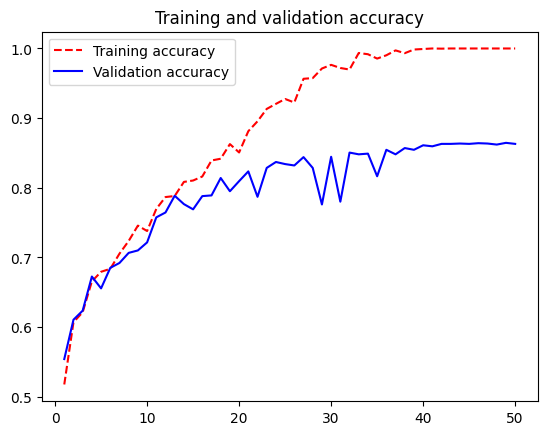

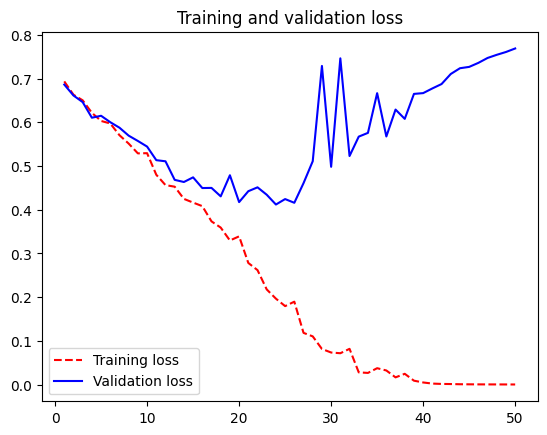

In [ ]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
test_model = keras.models.load_model("convnet_from_scratch.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - accuracy: 0.8441 - loss: 0.4041
Test accuracy: 0.844


#### Using data augmentation

Overfitting is caused by having too few samples to learn from, rendering you unable to train a model that can generalize to new data. Given infinite data, your model would be exposed to every possible aspect of the data distribution at hand: you would never overfit. Data augmentation takes the approach of generating more training data from existing training samples, by augmenting the samples via a number of random transformations that yield believable-looking images. The goal is that at training time, your model will never see the exact same picture twice. This helps expose the model to more aspects of the data and generalize better.

In Keras, this can be done via data augmentation layers. Such layers could be added in one of two ways:

- At the start of the model — Inside the model. In our case, the layers would come right before the Rescaling layer.

- Inside the data pipeline — Outside the model. In our case, we'd apply them to our Dataset via a map() call.

The main difference between these two options is that data augmentation done inside the model would be running on the GPU, just like the rest of the model. Meanwhile, data augmentation done in the data pipeline would be running on the CPU, typically in a parallel way on multiple CPU cores. Sometimes, there can be performance benefits to doing the former, but the latter is usually the better option.

In [ ]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
]

def data_augmentation(images, targets):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images, targets

augmented_train_dataset = train_dataset.map(
    data_augmentation, num_parallel_calls=8
)
augmented_train_dataset = augmented_train_dataset.prefetch(tf.data.AUTOTUNE)

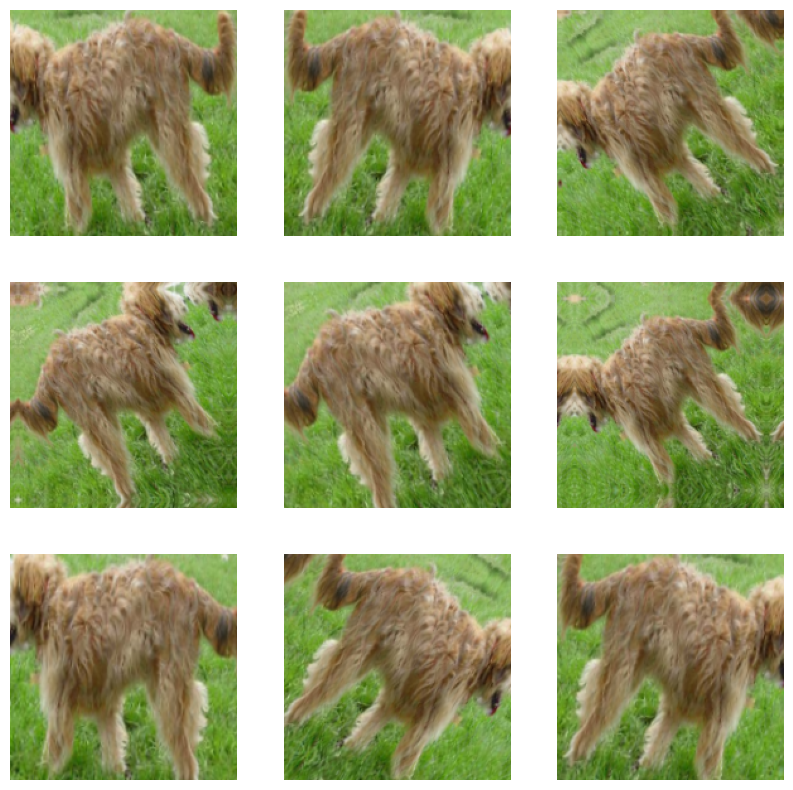

In [ ]:
plt.figure(figsize=(10, 10))
for image_batch, _ in train_dataset.take(1):
    image = image_batch[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image, _ = data_augmentation(image, None)
        augmented_image = keras.ops.convert_to_numpy(augmented_image)
        plt.imshow(augmented_image.astype("uint8"))
        plt.axis("off")

In [ ]:
inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1.0 / 255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=512, kernel_size=3, activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch_with_augmentation.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    augmented_train_dataset,
    epochs=100,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 394ms/step - accuracy: 0.5128 - loss: 0.6931 - val_accuracy: 0.5265 - val_loss: 0.6973
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 404ms/step - accuracy: 0.5913 - loss: 0.6687 - val_accuracy: 0.6095 - val_loss: 0.6593
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 420ms/step - accuracy: 0.6256 - loss: 0.6457 - val_accuracy: 0.5950 - val_loss: 0.6867
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 409ms/step - accuracy: 0.6506 - loss: 0.6332 - val_accuracy: 0.6630 - val_loss: 0.6291
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 404ms/step - accuracy: 0.6586 - loss: 0.6223 - val_accuracy: 0.6620 - val_loss: 0.6229
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 400ms/step - accuracy: 0.6653 - loss: 0.6052 - val_accuracy: 0.6865 - val_loss: 0.6012
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 412ms/step - accuracy: 0.6738 - loss: 0.6062 - val_accuracy: 0.6855 - val_loss: 0.6004
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 416ms/step - accuracy: 0.6696 - loss: 0.6088 - 

In [ ]:
test_model = keras.models.load_model(
    "convnet_from_scratch_with_augmentation.keras"
)
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

We get a test accuracy of 83.9%. By further tuning the model's configuration (such as the number of filters per convolution layer or the number of layers in the model), you may be able to get an even better accuracy, likely up to 90%. But it would prove difficult to go any higher just by training your own ConvNet from scratch because you have so little data to work with.

### Using a pretrained model

A common and highly effective approach to deep learning on small image datasets is to use a pretrained model. A pretrained model is a model that was previously trained on a large dataset, typically on a large-scale image-classification task. If this original dataset is large and general enough, then the spatial hierarchy of features learned by the pretrained model can effectively act as a generic model of the visual world.

#### Feature extraction with a pretrained model

Feature extraction consists of using the representations learned by a previously trained model to extract interesting features from new samples. These features are then run through a new classifier, which is trained from scratch.

As you saw previously, ConvNets used for image classification comprise two parts: they start with a series of pooling and convolution layers, and they end with a densely connected classifier. The first part is called the convolutional base or backbone of the model.
In the case of ConvNets, feature extraction consists of taking the convolutional base of a previously trained network, running the new data through it, and training a new classifier on top of the output.

![](https://deeplearningwithpython.io/images/ch08/swapping_fc_classifier.6e525b7a.png)

We will use the KerasHub library to create all pretrained models used in this book. KerasHub contains Keras implementations of popular pretrained model architectures paired with pretrained weights that can be downloaded to your machine. It contains a number of ConvNets like Xception, ResNet, EfficientNet and MobileNet, as well as larger, generative models we will use in the later chapters of this book.

KerasHub uses the term backbone to refer to the underlying feature extractor network without the classification head (it's a little easier to type than “convolutional base”). It also uses a special constructor called from_preset() that will download the configuration and weights for the Xception model.

Every pretrained ConvNet will do some rescaling and resizing of images before pretraining. It's important to make sure our input images match; otherwise, our model will need to relearn how to extract features from images with a totally different input range. Rather than keep track of which pretrained models use a [0, 1] input range for pixel values and which use a [-1, 1] range, we can use a KerasHub layer called ImageConverter that will rescale our images to match our pretrained checkpoint. It has the same special from_preset() constructor as the backbone class.

In [ ]:
import keras_hub

conv_base = keras_hub.models.Backbone.from_preset("xception_41_imagenet")

In [ ]:
preprocessor = keras_hub.layers.ImageConverter.from_preset(
    "xception_41_imagenet",
    image_size=(180, 180),
)

At this point, there are two ways you could proceed:

- Running the convolutional base over your dataset, recording its output to a NumPy array on disk, and then using this data as input to a standalone, densely connected classifier similar to those you saw in chapters 4 and 5. This solution is fast and cheap to run, because it only requires running the convolutional base once for every input image, and the convolutional base is by far the most expensive part of the pipeline. But for the same reason, this technique won't allow you to use data augmentation.

- Extending the model you have (conv_base) by adding Dense layers on top and running the whole thing end to end on the input data. This will allow you to use data augmentation because every input image goes through the convolutional base every time it's seen by the model. But for the same reason, this technique is far more expensive than the first.

##### 1. Fast feature extraction without data augmentation

In [ ]:
def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = preprocessor(images)
        features = conv_base.predict(preprocessed_images, verbose=0)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_labels = get_features_and_labels(augmented_train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

In [ ]:
train_features.shape

In [ ]:
inputs = keras.Input(shape=(6, 6, 2048))
x = layers.GlobalAveragePooling2D()(inputs)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

# compile model with:
# - optimizer: adam
# - loss: binary_crossentropy
# - metrics: accuracy
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

# fit model with 10 epochs
history = model.fit(
    train_features,
    train_labels,
    epochs=10,
    validation_data=(val_features, val_labels),
    callbacks=callbacks
)

In [ ]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
test_model = keras.models.load_model("feature_extraction.keras")
test_loss, test_acc = test_model.evaluate(test_features, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

You reach a validation accuracy of slightly over 98% — much better than you achieved in the previous section with the small model trained from scratch. This is a bit of an unfair comparison, however, because ImageNet contains many dog and cat instances, which means that our pretrained model already has the exact knowledge required for the task at hand. This won't always be the case when you use pretrained features.

However, the plots also indicate that you're overfitting almost from the start — despite using dropout with a fairly large rate. That's because this technique doesn't use data augmentation, which is essential for preventing overfitting with small image datasets.

We get test accuracy of ~98% — a very nice improvement over training a model from scratch!

##### 2. Feature extraction together with data augmentation

Let's review the second technique we mentioned for doing feature extraction, which is much slower and more expensive but allows you to use data augmentation during training: creating a model that chains the conv_base with a new dense classifier and training it end to end on the inputs.

To do this, we will first freeze the convolutional base. Freezing a layer or set of layers means preventing their weights from being updated during training. Here, if you don't do this, then the representations that were previously learned by the convolutional base will be modified during training. Because the Dense layers on top are randomly initialized, very large weight updates would be propagated through the network, effectively destroying the representations previously learned.



In [ ]:
import keras_hub

conv_base = keras_hub.models.Backbone.from_preset(
    "xception_41_imagenet",
    trainable=False,
)

In [ ]:
conv_base.trainable = True
len(conv_base.trainable_weights)

In [ ]:
conv_base.trainable = False
len(conv_base.trainable_weights)

In [ ]:
inputs = keras.Input(shape=(180, 180, 3))
x = preprocessor(inputs)
x = conv_base(x)
# GlobalAveragePooing2D layer
x = layers.GlobalAveragePooling2D()(x)
# Dense layer with 256 units
x = layers.Dense(256)(x)
# Dropout loayer with rate: 0.25
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_with_data_augmentation.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    augmented_train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

In [ ]:
test_model = keras.models.load_model(
    "feature_extraction_with_data_augmentation.keras"
)
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

We get a test accuracy of 98.4%. This is not an improvement over the previous model, which is a bit disappointing. This could be a sign that our data augmentation configuration does not exactly match the distribution of the test data. Let's see if we can do better with our latest attempt.

#### Fine-tuning a pretrained model

Another widely used technique for model reuse, complementary to feature extraction, is fine-tuning (see figure 8.15). Fine-tuning consists of unfreezing the frozen model base used for feature extraction and jointly training both the newly added part of the model (in this case, the fully connected classifier) and the base model. This is called fine-tuning because it slightly adjusts the more abstract representations of the model being reused to make them more relevant for the problem at hand.

The steps for fine-tuning a network are as follows:

1. Add your custom network on top of an already trained base network.
2. Freeze the base network.
3. Train the part you added.
4. Unfreeze the base network.
5. Jointly train both these layers and the part you added.

Note that you should not unfreeze “batch normalization” layers (BatchNormalization). Batch normalization and its effect on fine-tuning is explained in the next chapter.

You already completed the first three steps when doing feature extraction.

In [ ]:
# compile model using:
# - 'binary_crossentropy' loss
# - keras Adam optimizer with learning rate 1e-5
# - 'accuracy' metrics\

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

# fit model with:
# - augmented_train_dataset
# - 30 epochs
# - validation_dataset
# - the above callbacks

model.fit(augmented_train_dataset,
          epochs=30,
          validation_data=validation_dataset,
          callbacks=callbacks
)

In [ ]:
model = keras.models.load_model("fine_tuning.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

You get a test accuracy of 98.6% (again, your own results may be within half a percentage point). In the original Kaggle competition around this dataset, this would have been one of the top results. It's not quite a fair comparison, however, since you used pretrained features that already contained prior knowledge about cats and dogs, which competitors couldn't use at the time.

On the positive side, by using modern deep learning techniques, you managed to reach this result using only a small fraction of the training data that was available for the competition (about 10%). There is a huge difference between being able to train on 20,000 samples compared to 2,000 samples!

## Summary

- ConvNets excel at computer vision tasks. It's possible to train one from scratch, even on a very small dataset, with decent results.

- ConvNets work by learning a hierarchy of modular patterns and concepts to represent the visual world.

- On a small dataset, overfitting will be the main issue. Data augmentation is a powerful way to fight overfitting when you're working with image data.

- It's easy to reuse an existing ConvNet on a new dataset via feature extraction. This is a valuable technique for working with small image datasets.

- As a complement to feature extraction, you can use fine-tuning, which adapts to a new problem some of the representations previously learned by an existing model. This pushes performance a bit further.